/var/folders/c4/54xhkqmn06z28l_sd5vnm5700000gn/T/ipykernel_15956/1467178114.py:212: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


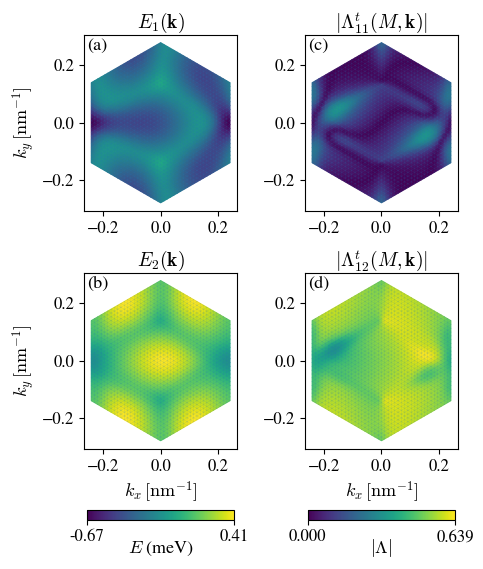

In [1]:
import os, glob, csv
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as mtri

import matplotlib
matplotlib.rcParams["mathtext.fontset"] = "cm"
matplotlib.rcParams["font.family"] = "STIXGeneral"
# ============================================================
# Optional: read k_index.csv (not used by default)
# ============================================================
def _read_k_index_table(in_dir):
    path = os.path.join(in_dir, "k_index.csv")
    with open(path, "r", newline="") as f:
        return [(int(r["k_index"]), float(r["kx"]), float(r["ky"]))
                for r in csv.DictReader(f)]

# ============================================================
# Collect two "flat" conduction bands: two smallest |Eplus|
# ============================================================
def collect_eplus_two_flat_bands(flat_dir, ref=0.00145947):
    files = sorted(glob.glob(os.path.join(flat_dir, "flat_k*.npz")))
    kx_list, ky_list, e0_list, e1_list, idx_list = [], [], [], [], []

    for f in files:
        z = np.load(f, allow_pickle=True)
        if ("Eplus_flat" not in z) or ("k" not in z) or ("k_index" not in z):
            continue

        k_index = int(z["k_index"])
        kvec    = np.asarray(z["k"], float).ravel()
        Eplus   = np.asarray(z["Eplus_flat"], float).ravel()
        if Eplus.size < 2:
            continue

        sel = np.argsort(np.abs(Eplus))[:2]   # two closest to 0
        e0 = (Eplus[sel[0]] - ref) * 1000.0   # meV
        e1 = (Eplus[sel[1]] - ref) * 1000.0

        kx_list.append(kvec[0]); ky_list.append(kvec[1])
        e0_list.append(float(e0)); e1_list.append(float(e1))
        idx_list.append(k_index)

    return (np.array(kx_list, float),
            np.array(ky_list, float),
            np.array(e0_list, float),
            np.array(e1_list, float),
            idx_list)

# ============================================================
# Collect |Lambda_ij| restricted to flat 2-band subspace:
#   pick two smallest |Eplus| indices sel
#   take 2x2 block Lbig[np.ix_(sel, sel)]
# ============================================================
def collect_lambda_elem_flat2(flat_dir, *, layer=0, sym_idx=0, elem=(0,0)):
    files = sorted(glob.glob(os.path.join(flat_dir, "flat_k*.npz")))
    kx_list, ky_list, v_list, idx_list = [], [], [], []
    i, j = elem

    for f in files:
        z = np.load(f, allow_pickle=True)
        if ("Eplus_flat" not in z) or ("k" not in z) or ("k_index" not in z):
            continue
        if (layer == 0 and "L0flat" not in z) or (layer == 1 and "L1flat" not in z):
            continue

        k_index = int(z["k_index"])
        kvec    = np.asarray(z["k"], float).ravel()
        Eplus   = np.asarray(z["Eplus_flat"], float).ravel()
        if Eplus.size < 2:
            continue

        sel = np.argsort(np.abs(Eplus))[:2]   # two closest-to-zero conduction bands

        Lall = np.asarray(z["L0flat"] if layer == 0 else z["L1flat"])
        if sym_idx >= Lall.shape[0]:
            continue
        Lbig = np.asarray(Lall[sym_idx], complex)   # (N,N)

        # flat 2-band block (2x2)
        L2 = Lbig[np.ix_(sel, sel)]
        #v  = float(np.imag(L2[i, j]))
        v  = float(np.abs(L2[i, j]))

        kx_list.append(kvec[0]); ky_list.append(kvec[1])
        v_list.append(v); idx_list.append(k_index)

    return (np.array(kx_list, float),
            np.array(ky_list, float),
            np.array(v_list, float),
            idx_list)

# ============================================================
# Plot helper
# ============================================================
def _tripcolor(ax, tri, vals, *,
               title=None, vmin=None, vmax=None,
               show_pts=False, show_edges=False,
               tickvals=(-0.2, 0.0, 0.2),
               xlabel=True, ylabel=True,
               title_size=14, label_size=13, tick_size=12):
    im = ax.tripcolor(tri, vals, shading="gouraud", vmin=vmin, vmax=vmax)
    if show_edges:
        ax.triplot(tri, lw=0.25, alpha=0.25)
    if show_pts:
        ax.scatter(tri.x, tri.y, s=4, alpha=0.25)
    ax.set_aspect("equal", adjustable="box")

    ax.set_xticks(tickvals); ax.set_yticks(tickvals)
    ax.tick_params(labelsize=tick_size)
    if xlabel:
        ax.set_xlabel(r"$k_x\,[\mathrm{nm}^{-1}]$", fontsize=label_size)
    if ylabel:
        ax.set_ylabel(r"$k_y\,[\mathrm{nm}^{-1}]$", fontsize=label_size)
    if title:
        ax.set_title(title, pad=3, fontsize=title_size)
    return im

# ============================================================
# Main 2x2 plot
# ============================================================
def plot_two_col_two_row_disp_and_lambda(
    flat_dir_disp,
    flat_dir_lambda,
    *,
    layer=0,
    sym_idx=0,
    out_path=None,
    show_points=False,
    show_edges=True,
    share_lambda_scale=True,
    ref_energy=0.00145947
):
    # --- Collect energies (two closest-to-zero conduction bands) ---
    kx, ky, e0, e1, _ = collect_eplus_two_flat_bands(flat_dir_disp, ref=ref_energy)
    if len(kx) < 3:
        raise RuntimeError(f"Not enough k points for energy triangulation: len={len(kx)}")

    tri_e  = mtri.Triangulation(kx, ky)
    vmin_e = float(min(e0.min(), e1.min()))
    vmax_e = float(max(e0.max(), e1.max()))

    # --- Collect lambda elements in flat 2-band subspace ---
    kx11, ky11, lam11, _ = collect_lambda_elem_flat2(
        flat_dir_lambda, layer=layer, sym_idx=sym_idx, elem=(0,0)
    )
    kx12, ky12, lam12, _ = collect_lambda_elem_flat2(
        flat_dir_lambda, layer=layer, sym_idx=sym_idx, elem=(0,1)
    )

    if len(kx11) < 3 or len(kx12) < 3:
        raise RuntimeError(
            f"Not enough k points for lambda triangulation: "
            f"len11={len(kx11)}, len12={len(kx12)}. "
            f"Check your flat_k*.npz contain Eplus_flat and L0flat/L1flat."
        )

    tri_11 = mtri.Triangulation(kx11, ky11)
    tri_12 = mtri.Triangulation(kx12, ky12)

    if share_lambda_scale:
        vmin_L = float(min(lam11.min(), lam12.min()))
        vmax_L = float(max(lam11.max(), lam12.max()))
    else:
        vmin_L = vmax_L = None

    # --- Figure & layout ---
    fig = plt.figure(figsize=(7.6, 6.6), constrained_layout=False)
    gs  = fig.add_gridspec(2, 2, wspace=-0.4, hspace=0.35)

    ax_a = fig.add_subplot(gs[0, 0])                             # (a) E1
    ax_b = fig.add_subplot(gs[1, 0], sharex=ax_a, sharey=ax_a)   # (b) E2
    ax_c = fig.add_subplot(gs[0, 1])                             # (c) |Λ11|
    ax_d = fig.add_subplot(gs[1, 1], sharex=ax_c, sharey=ax_c)   # (d) |Λ12|

    # --- Draw maps ---
    im_a = _tripcolor(ax_a, tri_e, e0, title=r"$E_{1}(\mathbf{k})$",
                      vmin=vmin_e, vmax=vmax_e, show_pts=show_points, show_edges=show_edges,
                      xlabel=False, ylabel=True)
    im_b = _tripcolor(ax_b, tri_e, e1, title=r"$E_{2}(\mathbf{k})$",
                      vmin=vmin_e, vmax=vmax_e, show_pts=show_points, show_edges=show_edges,
                      xlabel=True, ylabel=True)

    im_c = _tripcolor(ax_c, tri_11, lam11, title=r"$|\Lambda^{t}_{11}(M,\mathbf{k})|$",
                      vmin=vmin_L, vmax=vmax_L, show_pts=show_points, show_edges=show_edges,
                      xlabel=False, ylabel=False)
    im_d = _tripcolor(ax_d, tri_12, lam12, title=r"$|\Lambda^{t}_{12}(M,\mathbf{k})|$",
                      vmin=vmin_L, vmax=vmax_L, show_pts=show_points, show_edges=show_edges,
                      xlabel=True, ylabel=False)

    # --- Colorbars per column ---
    cbar_e = fig.colorbar(im_a, ax=[ax_a, ax_b], orientation="horizontal",
                          fraction=0.065, pad=0.12, shrink=0.4, aspect=15, use_gridspec=True)
    vmin, vmax = im_a.get_clim()
    cbar_e.set_ticks([vmin, vmax])
    cbar_e.set_label("$E$ (meV)", fontsize=13, labelpad=-4)
    cbar_e.set_ticklabels([f"{vmin:.2f}", f"{vmax:.2f}"])
    cbar_e.ax.tick_params(labelsize=12)

    cbar_L = fig.colorbar(im_c, ax=[ax_c, ax_d], orientation="horizontal",
                          fraction=0.065, pad=0.12, shrink=0.4, aspect=15, use_gridspec=True)
    vminL, vmaxL = im_c.get_clim()
    cbar_L.set_ticks([vminL, vmaxL])
    cbar_L.set_label(r"$|\Lambda|$", fontsize=13, labelpad=-6)
    cbar_L.set_ticklabels([f"{vminL:.3f}", f"{vmaxL:.3f}"])
    cbar_L.ax.tick_params(labelsize=12)

    # Panel tags
    for ax, tag in [(ax_a,"(a)"), (ax_b,"(b)"), (ax_c,"(c)"), (ax_d,"(d)")]:
        ax.text(0.02, 0.98, tag, transform=ax.transAxes, ha="left", va="top", fontsize=13)

    plt.tight_layout()
    if out_path:
        os.makedirs(os.path.dirname(out_path), exist_ok=True)
        fig.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()

# ============================================================
# Script entry
# ============================================================
if __name__ == "__main__":
    flat_dir_disp   = "lambda_triplet"   # <-- dispersion source
    flat_dir_lambda = "lambda_triplet"      # <-- Lambda source

    layer   = 0
    sym_idx = 0
    out_path = os.path.join("figs/", "fig2.pdf")

    plot_two_col_two_row_disp_and_lambda(
        flat_dir_disp,
        flat_dir_lambda,
        layer=layer,
        sym_idx=sym_idx,
        out_path=out_path,
        show_points=False,
        show_edges=True,
        share_lambda_scale=True,
        ref_energy=0.00145947
    )

